In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

root = Path.cwd().parent.parent
if str(root) not in sys.path:
    sys.path.append(str(root))

In [3]:
from src import config

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [5]:
import random, numpy as np, matplotlib.pyplot as plt

In [6]:
random.seed(42)

### ConvEncoder

In [7]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), # Downsample
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # Downsample
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # Downsample
            nn.BatchNorm2d(128),
            nn.LeakyReLU(),
            nn.Flatten() 
        )
        # 128 channels * 8 height * 12 width = 12288
        self.flattened_size = 128 * 8 * 12 #FROM INPUT HEIGHT AND WIDTH
        
        self.mu_layer = nn.Linear(self.flattened_size, latent_dim)
        self.logvar_layer = nn.Linear(self.flattened_size, latent_dim)
        
    def forward(self, x):
        h = self.net(x) # TODO: i dont understand the syntax here
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar       

### ConvDecoder

In [8]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.flattened_size = 128 * 8 * 12
        self.fc = nn.Linear(latent_dim, self.flattened_size)
        
        self.net = nn.Sequential(
            nn.Unflatten(1, (128, 8, 12)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=(1, 0)), # -> 16 x 23
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=(1, 1)), # -> 32 x 46
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=(1, 0)),  # -> 64 x 91
            nn.Sigmoid() 
        )
        
    def forward(self, z):
        h = self.fc(z)
        return self.net(h)

### Conv VAE

In [9]:
class ConvVAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.config = cfg
        self.encoder = Encoder(
            latent_dim=cfg.LATENT_DIM
        )
        self.decoder = Decoder(
            latent_dim=cfg.LATENT_DIM
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
      x_recon = self.decoder(z)
      return x_recon
  
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

### Dataset Class

In [10]:
class AudioSpectrogramDataset(Dataset):
    def __init__(self, dataset_dir, expected_shape=(config.INPUT_HEIGHT, config.INPUT_WIDTH), add_channel_dim=False):
        super().__init__()
        self.dataset_dir = dataset_dir
        self.file_paths = sorted(self.dataset_dir.rglob("*npy"))
        self.expected_shape = expected_shape
        self.add_channel_dim = add_channel_dim
        self.global_min = -80.0
        self.global_max = 0.0
        
        # mins, maxs = [], []
        # for fp in self.file_paths[:200]:
        #     x = np.load(fp)
        #     mins.append(x.min())
        #     maxs.append(x.max())

        # print("min of mins:", min(mins))
        # print("max of maxs:", max(maxs))
        # print("avg min:", sum(mins)/len(mins))
        # print("avg max:", sum(maxs)/len(maxs))
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, index):
        file_path = self.file_paths[index]
        x = np.load(file_path)
        x = (x - self.global_min) / (self.global_max - self.global_min)
        # x = np.clip(x, 0.0, 1.0)
        x = torch.tensor(x, dtype=torch.float32)
        if self.add_channel_dim: x = x.unsqueeze(0)
        
        return x, str(file_path)

## Activating GPU

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
device

device(type='cuda')

## Train and Test Data Preparation

In [13]:
npy_dir = Path("../..") / config.FEATURES_DIR

In [14]:
dataset = AudioSpectrogramDataset(dataset_dir=npy_dir)

In [15]:
BATCH_SIZE = 32

In [16]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

In [17]:
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [18]:
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=config.SHUFFLE)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
len(train_dataset), len(test_dataset)

(2000, 500)

## Training and Evaluating

In [20]:
def vae_loss(x_hat, x, beta, mu, logvar, epoch): # required for evaluation
    # recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    beta = min(1.0, epoch / 10)
    total = recon + beta * kl # TODO: use beta when and why?
    
    return total, recon, kl

In [21]:
def train_one_epoch(model, loader, optimizer, beta, epoch, device=device):
    model.train()
    total_sum = recon_sum = kl_sum = n = 0
    
    for x, _ in loader:
        x = x.to(device)
        x = x.unsqueeze(1)
        optimizer.zero_grad()
        x_hat, mu, logvar = model(x)
        loss, recon, kl = vae_loss(x_hat, x, beta, mu, logvar, epoch)
        loss.backward()
        optimizer.step()

        total_sum += loss.item()
        recon_sum += recon.item()
        kl_sum += kl.item()
        n += x.size(0) # TODO: = 1 because channel?  
              
    train_total = total_sum / max(n, 1)
    train_recon = recon_sum / max(n, 1)
    train_kl = kl_sum / max(n, 1)
    
    return {
        "loss": train_total,
        "recon": train_recon,
        "kl": train_kl
    }

In [22]:
def evaluate(model, loader, beta, epoch, device=device):
    model.eval()
    total_sum = recon_sum = kl_sum = n = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            x = x.unsqueeze(1)
            x_hat, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x_hat, x, beta, mu, logvar, epoch)
            
            total_sum += loss.item()
            recon_sum += recon.item()
            kl_sum += kl.item()
            n += x.size(0)

    test_total = total_sum / max(n, 1)
    test_recon = recon_sum / max(n, 1)
    test_kl = kl_sum / max(n, 1)
    
    return {
        "loss": test_total,
        "recon": test_recon,
        "kl": test_kl
    }

In [23]:
def train_vae(model, train_loader, test_loader, optimizer, beta, device=device):
    history = {"train_total": [], "test_total": [],
               "train_recon": [], "test_recon": [],
               "train_kl": [], "test_kl": []}
    for epoch in range(config.EPOCHS):
        train_stats = train_one_epoch(model=model, loader=train_loader, optimizer=optimizer, beta=beta, epoch=epoch, device=device)
        test_stats = evaluate(model=model, loader=test_loader, beta=beta, epoch=epoch, device=device)
        train_total = train_stats["loss"]
        test_total = test_stats["loss"]
        train_recon = train_stats["recon"]
        test_recon = test_stats["recon"]
        train_kl = train_stats["kl"]
        test_kl = test_stats["kl"]
        history["train_total"].append(train_total)
        history["test_total"].append(test_total)
        history["train_recon"].append(train_recon)
        history["test_recon"].append(test_recon)
        history["train_kl"].append(train_kl)
        history["test_kl"].append(test_kl)
        print(
            f"epoch {epoch:02d} | "
            f"train_total={train_total:.4f} recon={train_recon:.4f} kl={train_kl:.4f} | "
            f"test_total={test_total:.4f} recon={test_recon:.4f} kl={test_kl:.4f}"
        )
        
    return history

In [24]:
def plot_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history["train_total"], label="train total")
    plt.plot(history["test_total"], label="test total")
    plt.plot(history["train_recon"], label="train recon")
    plt.plot(history["test_recon"], label="test recon")
    plt.plot(history["train_kl"], label="train kl")
    plt.plot(history["test_kl"], label="test kl")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

## Single Iteration Model

In [25]:
model = ConvVAE(cfg=config).to(device)

In [26]:
model

ConvVAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.01)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.01)
      (9): Flatten(start_dim=1, end_dim=-1)
    )
    (mu_layer): Linear(in_features=12288, out_features=32, bias=True)
    (logvar_layer): Linear(in_features=12288, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=32, out_features=12288, bias=True)
    (net): Sequential(
      (0

In [27]:
optimizer = optim.Adam(model.parameters(), lr=config.LR)

In [28]:
history = train_vae(model=model, train_loader=train_loader, test_loader=test_loader, optimizer=optimizer, beta=50.0, device=device)

epoch 00 | train_total=7.7606 recon=7.7606 kl=362.6365 | test_total=4.6143 recon=4.6143 kl=16.0227
epoch 01 | train_total=4.0143 recon=3.5405 kl=4.7384 | test_total=3.3060 recon=3.0009 kl=3.0508
epoch 02 | train_total=3.1595 recon=2.7449 kl=2.0729 | test_total=2.9528 recon=2.5665 kl=1.9316
epoch 03 | train_total=2.8824 recon=2.4159 kl=1.5553 | test_total=2.7461 recon=2.3098 kl=1.4543
epoch 04 | train_total=2.7293 recon=2.2281 kl=1.2529 | test_total=2.7253 recon=2.2135 kl=1.2794
epoch 05 | train_total=2.6336 recon=2.1076 kl=1.0520 | test_total=2.6674 recon=2.1558 kl=1.0233
epoch 06 | train_total=2.6182 recon=2.0810 kl=0.8953 | test_total=2.6051 recon=2.0784 kl=0.8777
epoch 07 | train_total=2.5680 recon=2.0192 kl=0.7841 | test_total=2.5903 recon=2.0575 kl=0.7612
epoch 08 | train_total=2.5548 recon=2.0128 kl=0.6775 | test_total=2.5614 recon=2.0310 kl=0.6629
epoch 09 | train_total=2.5481 recon=1.9922 kl=0.6176 | test_total=2.5514 recon=1.9746 kl=0.6409
epoch 10 | train_total=2.5435 recon=1

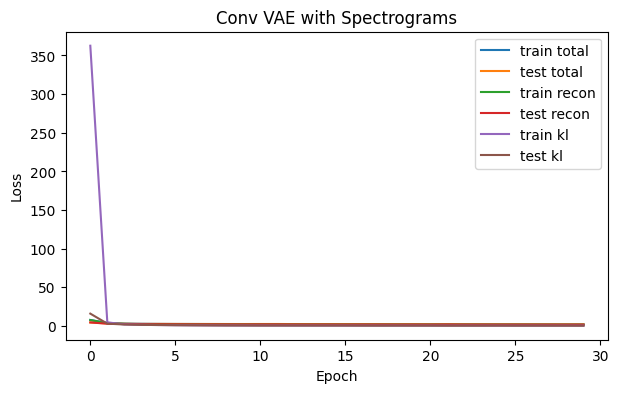

In [29]:
plot_history(history, "Conv VAE with Spectrograms")

## Extract Latent Features & Lyric Embeddings

In [30]:
def show_reconstructions(model, dataset, n=10, device=device):
    model.eval()
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    
    with torch.no_grad():
        for i in range(n):
            # Get a real sample
            print(dataset[i][1])
            x = dataset[i][0].unsqueeze(0).unsqueeze(0).to(device)
            x_hat, _, _ = model(x)
            
            # Original Spectrogram
            img_org = x.squeeze().cpu().numpy()
            axes[i, 0].imshow(img_org, origin='lower', aspect='auto')
            axes[i, 0].set_title(f"Original {i}")
            
            # Reconstructed Spectrogram
            img_recon = x_hat.squeeze().cpu().numpy()
            axes[i, 1].imshow(img_recon, origin='lower', aspect='auto')
            axes[i, 1].set_title(f"Reconstructed {i}")
            
    plt.tight_layout()
    plt.show()

..\..\data\features\MT0008386252_clip_8.npy
..\..\data\features\MT0041030749_clip_2.npy


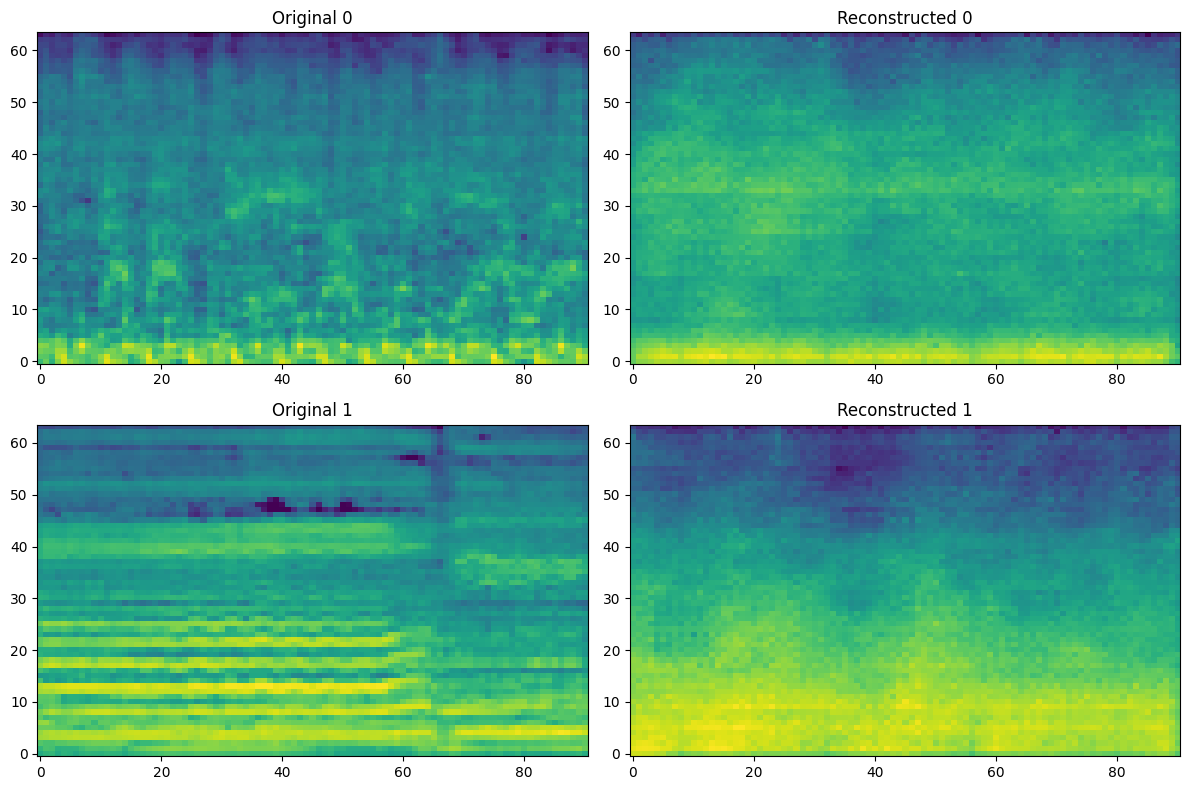

In [31]:
show_reconstructions(model=model, dataset=train_dataset, n=2)

In [32]:
#DIFFERENT FROM THE PREVIOUS EASY TASK FUNCTION
def extract_latents_with_names(model, loader, device=device):
    model.eval()
    latents = []
    names = []
    with torch.no_grad():
        for x, filenames in loader:
            x = x.to(device)
            x = x.unsqueeze(1)
            mu, _ = model.encoder(x)
            latents.append(mu.cpu().numpy())
            names.extend(filenames)
            
    return np.concatenate(latents,axis=0), names

In [33]:
#DIFFERENT FROM THE PREVIOUS EASY TASK FUNCTION
latent_vecs1,audio_names1 = extract_latents_with_names(model=model, loader=train_loader)
latent_vecs2,audio_names2 = extract_latents_with_names(model=model, loader=test_loader)
latent_vecs = np.concatenate([latent_vecs1, latent_vecs2], axis=0)
audio_names = np.concatenate([audio_names1, audio_names2], axis=0)

print(f"Train shape: {latent_vecs1.shape} ")
print(f"Test shape:  {latent_vecs2.shape} ")
print(f"Total shape: {latent_vecs.shape} ")

Train shape: (2000, 32) 
Test shape:  (500, 32) 
Total shape: (2500, 32) 


In [34]:
#ADDITIONAL CODE TO FIND LYRICS
LYRICS_DATASET_ROOT = Path("C:/Users/User/Downloads/VAE project/MERGE_Lyrics_Balanced") 
LYRIC_FEATURES_DIR = root / "data" / "lyric_features"
print(LYRIC_FEATURES_DIR)

c:\Users\User\Downloads\VAE project\vae-audio-clustering\data\lyric_features


In [35]:
#ADDITIONAL CODE TO FIND LYRICS
X_hybrid = []

for i, full_name in enumerate(audio_names):
    # 1. Get the parent stem (remove _clip_x)
    parent_stem = full_name.split('_')[0]
    parent_stem = parent_stem.split('\\')[-1]
    # 2. Get the audio vector for this specific row
    z_audio = latent_vecs[i] # Size 32
    
    # 3. Load the corresponding lyric vector
    # We use the parent_stem to find the lyric file
    lyric_path = LYRIC_FEATURES_DIR / f"{parent_stem}.npy"
    # print(lyric_path)
    
    if lyric_path.exists():
        z_text = np.load(lyric_path) # Size 384
        
        # 4. Concatenate: [32] + [786] = [800]
        z_combined = np.concatenate([z_audio, z_text])
        X_hybrid.append(z_combined)
    else:
        print(f"Warning: No lyrics for {parent_stem}")

X_hybrid = np.array(X_hybrid)

In [36]:
X_hybrid.shape

(2500, 800)

## K-means of Latent+Lyrics Features (Conv VAE Model for Medium Task)

In [37]:
X_hybrid

array([[ 1.07989386e-01,  5.19938588e-01, -5.05566180e-01, ...,
         2.47661285e-02, -6.20391145e-02, -1.02450177e-02],
       [-3.74824524e-01, -1.51446881e-02, -6.99822426e-01, ...,
        -2.44670548e-02, -7.75268078e-02, -1.13670984e-02],
       [-1.86790061e+00, -6.28493845e-01, -2.14537919e-01, ...,
         2.45365277e-02, -5.81904165e-02, -9.15042241e-04],
       ...,
       [ 4.47090268e-02, -1.67884186e-01,  6.83297634e-01, ...,
         3.34036313e-02, -5.39930835e-02, -3.23416293e-02],
       [-8.58803689e-01, -6.62786514e-02, -5.43020964e-02, ...,
        -5.47524728e-02, -2.78847147e-04, -5.32997698e-02],
       [ 1.39325917e+00,  1.67022601e-01,  6.66416883e-01, ...,
        -4.21772059e-03, -4.39380705e-02, -2.80517507e-02]],
      shape=(2500, 800), dtype=float32)

In [38]:
import pandas as pd
X_hybrid=pd.DataFrame(X_hybrid )
X_hybrid.head()

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
0,0.107989,0.519939,-0.505566,-0.287904,-0.718388,-0.810652,-1.131430,-3.199533,-0.480969,-0.030119,...,-0.099549,0.005869,0.005240,0.072202,-0.032023,-0.027808,-0.010037,0.024766,-0.062039,-0.010245
1,-0.374825,-0.015145,-0.699822,-0.174115,-0.517107,0.066803,-1.392305,2.675259,0.107236,-0.417450,...,-0.057210,-0.001022,0.003217,0.016943,0.009744,0.048408,-0.028768,-0.024467,-0.077527,-0.011367
2,-1.867901,-0.628494,-0.214538,-0.016087,1.241994,-0.262922,1.116529,0.602521,0.135270,0.504808,...,-0.043110,0.019846,-0.018886,-0.007292,-0.010909,0.003429,-0.017972,0.024537,-0.058190,-0.000915
3,-0.581368,0.227284,0.584986,0.149585,1.611402,0.351794,0.065995,1.560908,-0.122897,-0.038918,...,-0.067396,0.006705,0.033713,0.034209,-0.021372,0.060671,-0.027774,-0.005320,0.006439,-0.031315
4,0.016688,0.190275,0.166297,0.265842,0.168622,0.681453,0.008532,-0.275350,0.422567,-0.265078,...,-0.041399,-0.009399,0.046564,0.017177,-0.024949,-0.061986,-0.075055,-0.048761,-0.085919,-0.014190


In [39]:
X_hybrid.describe()

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,...,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,-0.654540,-0.065353,-0.052674,0.024915,0.793543,0.211411,0.121322,0.484866,0.075065,-0.009735,...,-0.025838,-0.002853,0.012728,0.001246,-0.017044,-0.003480,-0.033128,-0.004572,-0.022492,-0.014866
std,1.050926,0.429277,0.715704,0.244377,0.968879,0.693785,0.717951,1.230051,0.258707,0.405512,...,0.031742,0.025370,0.033978,0.023234,0.016178,0.035347,0.025087,0.023957,0.031803,0.020952
min,-4.971122,-1.714391,-3.121507,-0.937355,-3.021253,-3.553912,-3.320385,-4.950962,-0.758363,-1.424697,...,-0.123760,-0.083610,-0.097509,-0.105466,-0.070846,-0.144655,-0.111684,-0.080749,-0.110829,-0.082614
25%,-1.303251,-0.336814,-0.548777,-0.113492,0.198492,-0.199320,-0.319422,-0.236356,-0.097522,-0.282892,...,-0.047593,-0.019647,-0.009397,-0.013578,-0.027779,-0.026110,-0.050614,-0.020530,-0.043997,-0.028864
50%,-0.579263,-0.057718,0.060715,0.015252,0.810261,0.280816,0.046530,0.539516,0.052183,-0.091889,...,-0.027690,-0.002531,0.013122,0.001528,-0.017277,-0.003553,-0.034116,-0.005290,-0.024050,-0.014901
75%,0.121449,0.200529,0.463673,0.161108,1.394278,0.633183,0.619723,1.331142,0.226161,0.219649,...,-0.005309,0.013745,0.035835,0.017078,-0.006851,0.019857,-0.016724,0.011395,-0.002770,-0.000945
max,2.054804,2.027422,2.231662,1.306907,5.583642,2.728029,3.049645,3.995802,1.397356,1.296874,...,0.096007,0.081997,0.133241,0.082623,0.045397,0.119987,0.058392,0.082305,0.092216,0.053246


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

%matplotlib inline

In [41]:
track_inertia={}
silhouette={}
ch_index={}
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init = 'k-means++', random_state=42)
    kmeans.fit(X_hybrid)
    track_inertia[k] = kmeans.inertia_
    silhouette[k] = silhouette_score(X_hybrid, kmeans.labels_) 
    ch_index[k] = calinski_harabasz_score(X_hybrid, kmeans.labels_)

<Axes: >

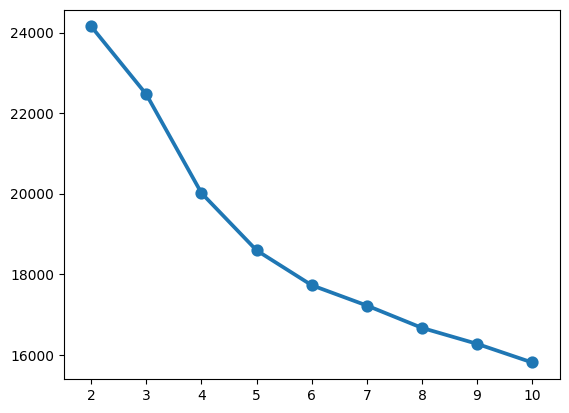

In [42]:
sns.pointplot(x = list(track_inertia.keys()), y = list(track_inertia.values()))

<Axes: >

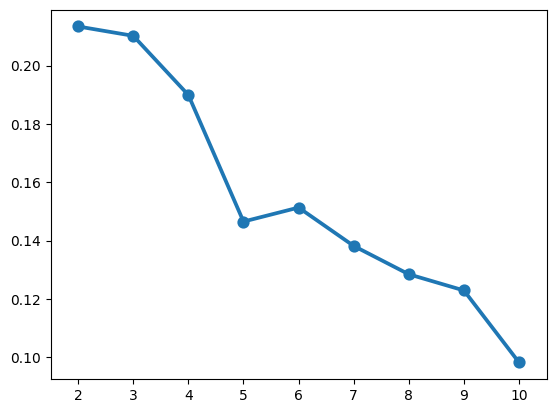

In [43]:
sns.pointplot(x = list(silhouette.keys()), y = list(silhouette.values()))

<Axes: >

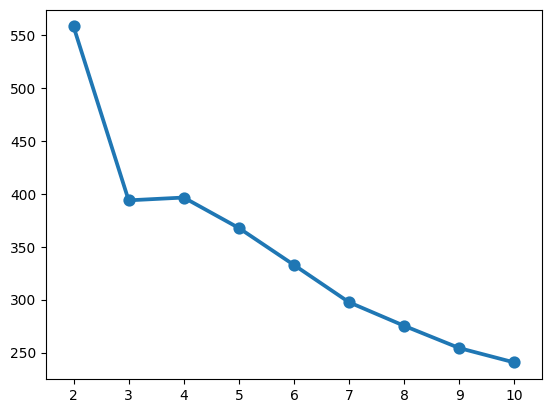

In [44]:
sns.pointplot(x = list(ch_index.keys()), y = list(ch_index.values()))

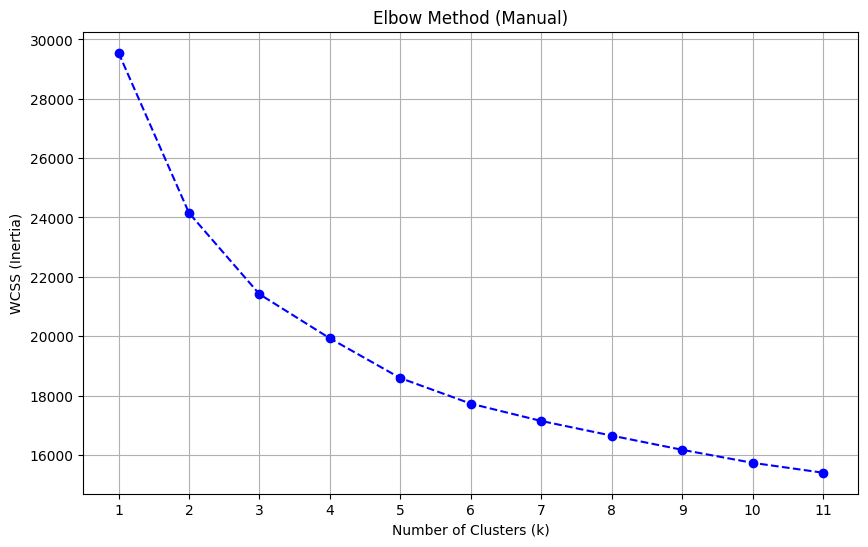

In [45]:
wcss = []
k_values = range(1, 12)

for k in k_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=0)
    km.fit(X_hybrid)
    wcss.append(km.inertia_) # inertia_ is the "WCSS" value you need for the elbow


plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method (Manual)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

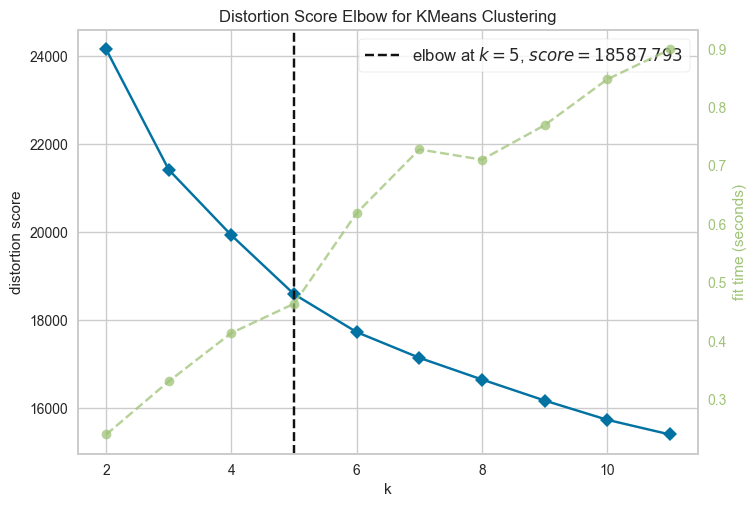

In [46]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model2 = KMeans(init='k-means++', random_state=0, n_init=10)

visualizer = KElbowVisualizer(model2, k=(2, 12), timings=True, force_model=True)

visualizer.fit(X_hybrid)        
visualizer.show()

optimal_k = visualizer.elbow_value_

In [47]:
optimal_k

np.int64(5)

In [48]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = optimal_k,init = "k-means++",max_iter = 300,n_init=10,random_state=0)
kmeans.fit(X_hybrid)
vae_clusters = kmeans.predict(X_hybrid)
vae_sil_kmeans=silhouette_score(X_hybrid,kmeans.labels_)
vae_dav_kmeans = davies_bouldin_score(X_hybrid, kmeans.labels_)
vae_ch_kmeans = calinski_harabasz_score(X_hybrid, kmeans.labels_)
print(f"Silhouette Score: {vae_sil_kmeans:.4f}")
print(f"Davies Bouldin Score: {vae_dav_kmeans:.4f}")
print(f"Calinski Harabasz Score: {vae_ch_kmeans:.4f}")

Silhouette Score: 0.1504
Davies Bouldin Score: 1.9562
Calinski Harabasz Score: 367.9223


## DBSCAN Clustering of Latent Audio+Lyrics Features (Conv VAE Model for Medium Task)

In [49]:
from sklearn.cluster import DBSCAN
# eps: The maximum distance between two samples for them to be considered as in the same neighborhood
# min_samples: The number of samples in a neighborhood for a point to be a core point
dbscan = DBSCAN(eps=2.5, min_samples=5) 
vae_clusters_db = dbscan.fit_predict(X_hybrid)
# Note: DBSCAN labels noise as -1. Silhouette score requires at least 2 clusters (excluding noise).
n_clusters_ = len(set(vae_clusters_db)) - (1 if -1 in vae_clusters_db else 0)

if n_clusters_ > 1:
    vae_sil_db = silhouette_score(X_hybrid, vae_clusters_db)
    vae_dav_db = davies_bouldin_score(X_hybrid, vae_clusters_db)
    vae_ch_db = calinski_harabasz_score(X_hybrid, vae_clusters_db)
    print(f"DBSCAN Clusters found: {n_clusters_}")
    print(f"Silhouette Score: {vae_sil_db:.4f}")
    print(f"Davies Bouldin Score: {vae_dav_db:.4f}")
    print(f"Calinski Harabasz Score: {vae_ch_db:.4f}")
else:
    print("DBSCAN only found 1 cluster or noise. Try adjusting 'eps'.")

DBSCAN Clusters found: 2
Silhouette Score: 0.1698
Davies Bouldin Score: 2.4158
Calinski Harabasz Score: 127.3877


## Agglomerative Clustering of Latent Audio+Lyrics Features (Conv VAE Model for Medium Task)

In [50]:
from sklearn.cluster import AgglomerativeClustering

# We use the optimal_k from your KElbowVisualizer
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
vae_clusters_agg = agg_clustering.fit_predict(X_hybrid)

vae_sil_agg = silhouette_score(X_hybrid, vae_clusters_agg)
vae_dav_agg = davies_bouldin_score(X_hybrid, vae_clusters_agg)
vae_ch_agg = calinski_harabasz_score(X_hybrid, vae_clusters_agg)
print(f"Silhouette Score: {vae_sil_agg:.4f}")
print(f"Davies Bouldin Score: {vae_dav_agg:.4f}")
print(f"Calinski Harabasz Score: {vae_ch_agg:.4f}")

Silhouette Score: 0.1307
Davies Bouldin Score: 2.0588
Calinski Harabasz Score: 324.4373


## PCA + Kmeans

In [51]:
def loader_to_numpy(loader):
    xs = []
    for x,_ in loader:
        xs.append(x.view(x.size(0), -1).numpy())
    return np.concatenate(xs)

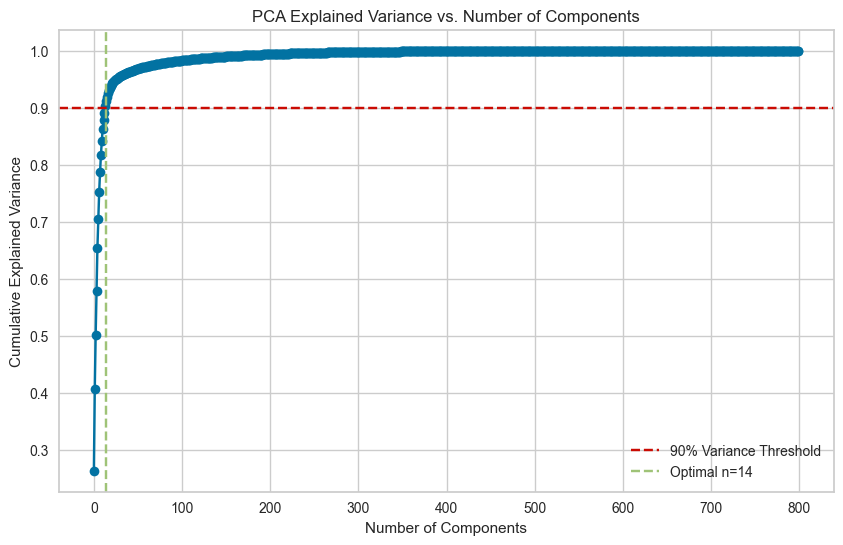

Optimal components for 90% variance: 14


In [52]:
from sklearn.decomposition import PCA

X_train = loader_to_numpy(train_loader)
X_test = loader_to_numpy(test_loader)

X_all = np.concatenate([X_hybrid], axis=0)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


pca_full = PCA().fit(X_all)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
optimal_n = np.where(cumulative_variance >= 0.90)[0][0] + 1

plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance, marker='o', linestyle='-') # removed 'loc'
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.axvline(x=optimal_n, color='g', linestyle='--', label=f'Optimal n={optimal_n}')
plt.title('PCA Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend(loc='best')
plt.grid(True)
plt.show()

print(f"Optimal components for 90% variance: {optimal_n}")

In [53]:
optimal_n

np.int64(14)

In [55]:
pca = PCA(n_components=optimal_n, random_state=42)
X_pca = pca.fit_transform(X_hybrid)

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
pca_clusters = kmeans.fit_predict(X_pca)

pca_sil = silhouette_score(X_pca, pca_clusters)
pca_ch = calinski_harabasz_score(X_pca, pca_clusters)

print(f"--- PCA + KMeans Baseline ---")
print(f"Silhouette Score: {round(pca_sil, 4)}")
print(f"Calinski-Harabasz Index: {round(pca_ch, 4)}")

--- PCA + KMeans Baseline ---
Silhouette Score: 0.1767
Calinski-Harabasz Index: 434.9176


## Visualize t-sne for 
## 1)PCA+Kmeans
## 2)ConvVAE+Kmeans 
## on audio+lyric features  

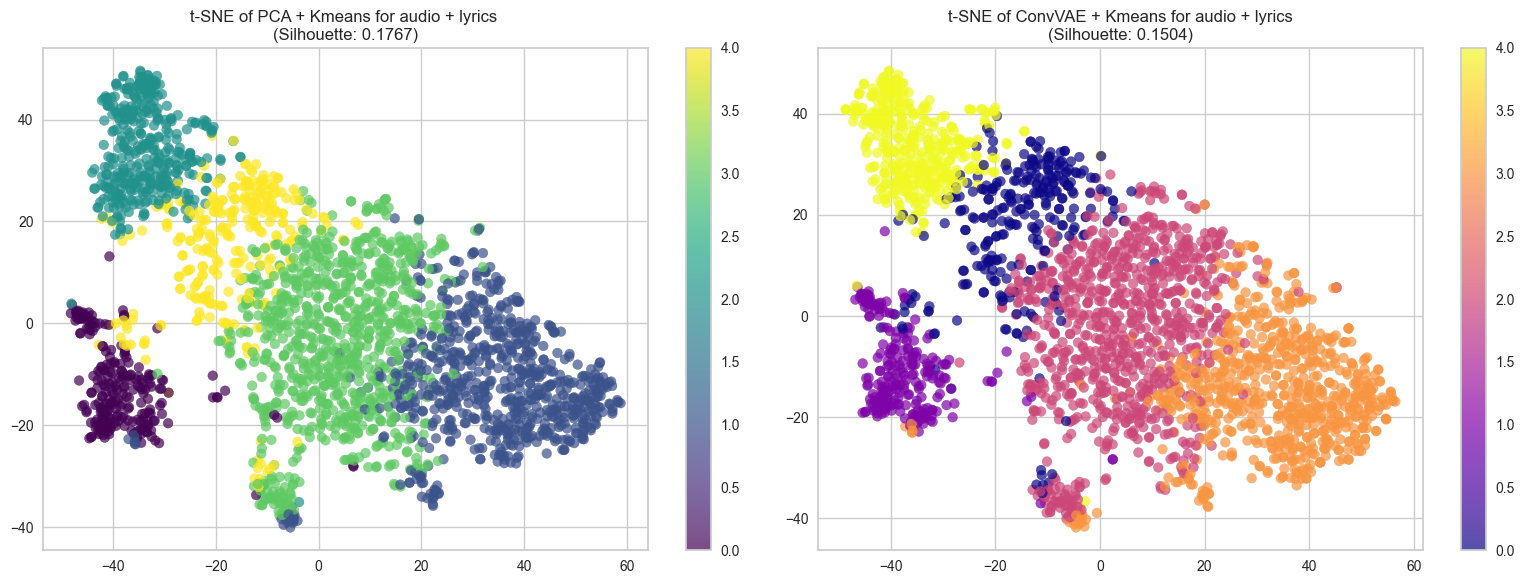

In [59]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_comparison(pca_latents, vae_latents, pca_clusters, vae_clusters):

    tsne_pca = TSNE(n_components=2, random_state=42).fit_transform(pca_latents)
    
    tsne_vae = TSNE(n_components=2, random_state=42).fit_transform(vae_latents)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    scatter1 = ax1.scatter(tsne_pca[:, 0], tsne_pca[:, 1], c=pca_clusters, cmap='viridis', alpha=0.7)
    ax1.set_title(f"t-SNE of PCA + Kmeans for audio + lyrics \n(Silhouette: {round(pca_sil, 4)})")
    fig.colorbar(scatter1, ax=ax1)
    
    scatter2 = ax2.scatter(tsne_vae[:, 0], tsne_vae[:, 1], c=vae_clusters, cmap='plasma', alpha=0.7)
    ax2.set_title(f"t-SNE of ConvVAE + Kmeans for audio + lyrics\n(Silhouette: {round(vae_sil_kmeans,4)})")
    fig.colorbar(scatter2, ax=ax2)
    
    plt.tight_layout()
    plt.show()

plot_tsne_comparison(X_pca, X_hybrid, pca_clusters, vae_clusters)

## Visualize t-sne for 
## 3)ConvVae+DBSCAN
## 4)ConvVae+Agglomerative
## on audio+lyric features 

Computing t-SNE embeddings (this may take a minute)...


C:\Users\User\AppData\Local\Temp\ipykernel_7404\1589583761.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Spectral')(np.linspace(0, 1, len(unique_labels)))


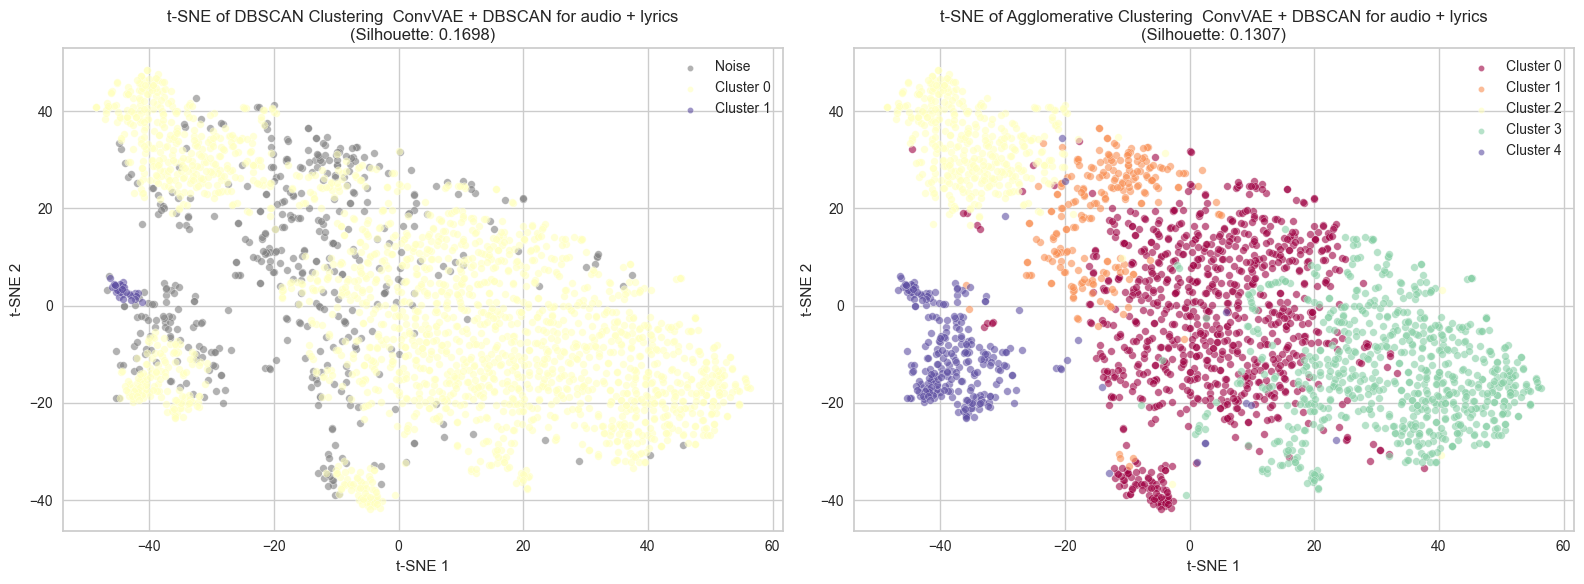

In [61]:
def plot_clustering_comparison(X_data, cluster_list, titles, scores):
    """
    X_data: The hybrid feature matrix (X_hybrid)
    cluster_list: List of cluster label arrays [dbscan_labels, agg_labels, ...]
    titles: List of titles for each subplot
    scores: List of Silhouette scores for each subplot
    """
    # 1. Compute t-SNE once for the shared data to ensure consistent spatial layout
    print("Computing t-SNE embeddings (this may take a minute)...")
    tsne_results = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto').fit_transform(X_data)

    n_plots = len(cluster_list)
    fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 6))
    
    # Handle single plot case
    if n_plots == 1: axes = [axes]

    for i, (labels, title, score) in enumerate(zip(cluster_list, titles, scores)):
        # Use a specific colormap where -1 (noise) stands out if it's DBSCAN
        # We'll map noise to a distinct 'gray' color manually if detected
        unique_labels = np.unique(labels)
        colors = plt.cm.get_cmap('Spectral')(np.linspace(0, 1, len(unique_labels)))
        
        for idx, label in enumerate(unique_labels):
            mask = (labels == label)
            color = 'gray' if label == -1 else colors[idx]
            label_text = "Noise" if label == -1 else f"Cluster {label}"
            
            axes[i].scatter(
                tsne_results[mask, 0], 
                tsne_results[mask, 1], 
                c=[color], 
                label=label_text, 
                alpha=0.6, 
                edgecolors='w', 
                s=30
            )

        axes[i].set_title(f"t-SNE of {title}  ConvVAE + DBSCAN for audio + lyrics\n(Silhouette: {round(score, 4)})")
        axes[i].set_xlabel("t-SNE 1")
        axes[i].set_ylabel("t-SNE 2")
        # Only show legend if there aren't too many clusters
        if len(unique_labels) < 15:
            axes[i].legend(loc='best', markerscale=0.8, fontsize='small')

    plt.tight_layout()
    plt.show()


plot_clustering_comparison(
    X_data=X_hybrid, 
    cluster_list=[vae_clusters_db, vae_clusters_agg], 
    titles=["DBSCAN Clustering", "Agglomerative Clustering"],
    scores=[vae_sil_db, vae_sil_agg]
)